# **Άσκηση 1.**

In [2]:
%pip install ucimlrepo

Κατεβάζουμε το ucimlrepo για να κάνουμε import τα Data από το Dataset

**Ερώτημα Α.**

In [3]:
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split

iris = fetch_ucirepo(id=53)
X = iris.data.features
y = iris.data.targets

print(iris.metadata)
print(iris.variables)

# Διαχωρισμός των δεδομένων
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=None)

# Εκτύπωση
print("\nΔείγματα εκπαίδευσης (χαρακτηριστικά):")
print(X_train)
print("\nΔείγματα εκπαίδευσης (στόχοι):")
print(y_train)
print("\nΔείγματα δοκιμής (χαρακτηριστικά):")
print(X_test)
print("\nΔείγματα δοκιμής (στόχοι):")
print(y_test)

{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'published_in': 'Significance, 2021', 'year': 2021, 'url': 'https://www.semanticscholar.org/paper/4599862ea877863669a6a8e63a3c707a787d5d7e', 'doi': '1740-9713.01589'}, 'add

**Ερώτημα Β.**

In [4]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo


iris = fetch_ucirepo(id=53)
X = iris.data.features
y = iris.data.targets

# Διαχωρισμός των δεδομένων
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=None)

# Δημιουργία του νευρωνικού δικτύου
# logistic==sigmoid
neural_network = MLPClassifier(hidden_layer_sizes=(30,), activation='logistic', max_iter=2000)

# Εκπαίδευση
neural_network.fit(X_train, y_train)

# Εκτύπωση
print(f"Η ακρίβεια του μοντέλου στο σετ εκπαίδευσης: {neural_network.score(X_train, y_train):.2f}")
print(f"Η ακρίβεια του μοντέλου στο σετ δοκιμής: {neural_network.score(X_test, y_test):.2f}")


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1098: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Η ακρίβεια του μοντέλου στο σετ εκπαίδευσης: 0.98
Η ακρίβεια του μοντέλου στο σετ δοκιμής: 0.97


**Ερώτημα Γ.**

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1098: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1098: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1098: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y

Η ακρίβεια του μοντέλου στο σετ εκπαίδευσης: 0.99
Η ακρίβεια του μοντέλου στο σετ δοκιμής: 0.97
Πίνακας Σύγχυσης:
[[ 7  0  0]
 [ 0 13  0]
 [ 0  1  9]]


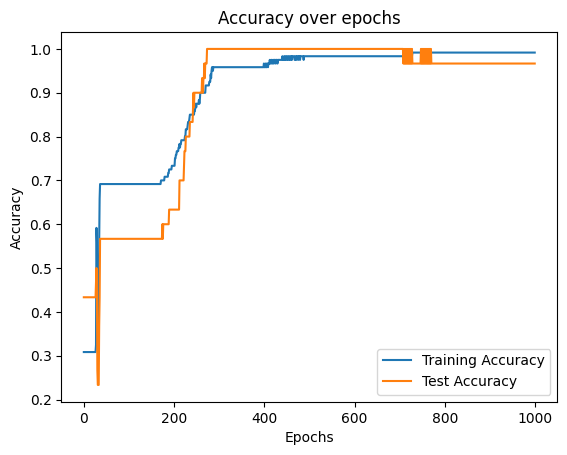

In [5]:
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

iris = fetch_ucirepo(id=53)
X = iris.data.features
y = iris.data.targets

# Διαχωρισμός των δεδομένων
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=None)

# Δημιουργία του νευρωνικού δικτύου
neural_network = MLPClassifier(hidden_layer_sizes=(30,), activation='logistic', max_iter=1, warm_start=True)

# Κενές λίστες για αποθήκευση
train_accuracy = []
test_accuracy = []

# Εκπαίδευση του μοντέλου
for i in range(1000):
    neural_network.fit(X_train, y_train)
    train_accuracy.append(neural_network.score(X_train, y_train))
    test_accuracy.append(neural_network.score(X_test, y_test))

# Εκτύπωση

print(f"Η ακρίβεια του μοντέλου στο σετ εκπαίδευσης: {train_accuracy[-1]:.2f}")
print(f"Η ακρίβεια του μοντέλου στο σετ δοκιμής: {test_accuracy[-1]:.2f}")

y_pred = neural_network.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Πίνακας Σύγχυσης:")
print(conf_matrix)

# Δημιουργία διαγράμματος
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(test_accuracy, label='Test Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


**Ερώτημα Δ.**

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1098: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1098: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1098: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y

Η ακρίβεια του μοντέλου στο σετ εκπαίδευσης: 0.97
Η ακρίβεια του μοντέλου στο σετ δοκιμής: 0.97
Πίνακας Σύγχυσης:
[[13  0  0]
 [ 0  5  0]
 [ 0  1 11]]


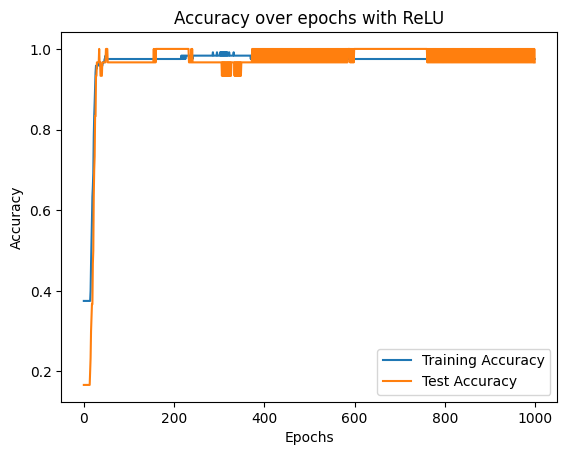

In [9]:
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

iris = fetch_ucirepo(id=53)
X = iris.data.features
y = iris.data.targets

# Διαχωρισμός των δεδομένων
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=None)

# Δημιουργία του νευρωνικού δικτύου με ReLU
neural_network = MLPClassifier(hidden_layer_sizes=(30,), activation='relu', max_iter=1, warm_start=True)

# Κενές λίστες για αποθήκευση
train_accuracy = []
test_accuracy = []

# Εκπαίδευση του μοντέλου
for i in range(1000):
    neural_network.fit(X_train, y_train)
    train_accuracy.append(neural_network.score(X_train, y_train))
    test_accuracy.append(neural_network.score(X_test, y_test))

# Εκτύπωση

print(f"Η ακρίβεια του μοντέλου στο σετ εκπαίδευσης: {train_accuracy[-1]:.2f}")
print(f"Η ακρίβεια του μοντέλου στο σετ δοκιμής: {test_accuracy[-1]:.2f}")

y_pred = neural_network.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Πίνακας Σύγχυσης:")
print(conf_matrix)

# Δημιουργία διαγράμματος
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(test_accuracy, label='Test Accuracy')
plt.title('Accuracy over epochs with ReLU')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


**Ερώτημα Ε.**

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1098: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1098: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1098: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y

Ακρίβεια εκπαίδευσης: 0.97
Ακρίβεια δοκιμής: 1.00
Πίνακας Σύγχυσης:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


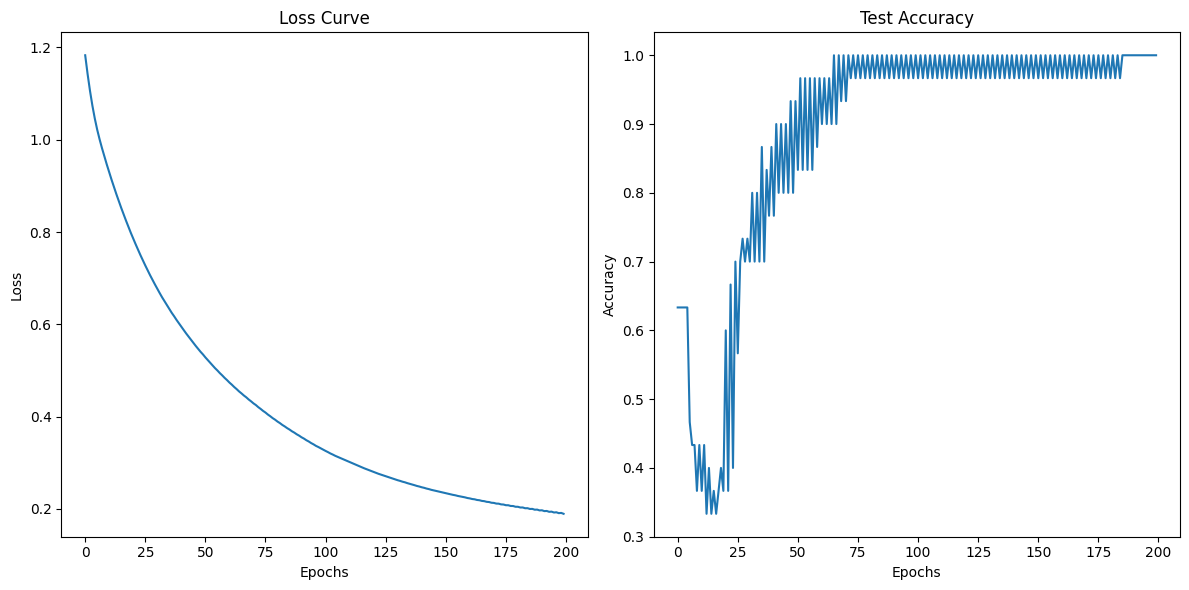

In [34]:
from ucimlrepo import fetch_ucirepo
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

iris = fetch_ucirepo(id=53)
X = iris.data.features
y = iris.data.targets

# Διαχωρισμός των δεδομένων
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Δημιουργία του νευρωνικού δικτύου με dropout και L2 regularization
neural_network = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam',
                               alpha=0.001, learning_rate_init=0.001, max_iter=1, warm_start=True,
                               random_state=42)

# Κενές λίστες για αποθήκευση
train_accuracy = []
test_accuracy = []

# Εκπαίδευση του μοντέλου
for i in range(200):
    neural_network.fit(X_train, y_train)
    train_accuracy.append(neural_network.score(X_train, y_train))
    test_accuracy.append(neural_network.score(X_test, y_test))

# Εκτύπωση

print(f"Ακρίβεια εκπαίδευσης: {train_accuracy[-1]:.2f}")
print(f"Ακρίβεια δοκιμής: {test_accuracy[-1]:.2f}")

y_pred = neural_network.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Πίνακας Σύγχυσης:")
print(conf_matrix)

# Δημιουργία γραφημάτων

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(neural_network.loss_curve_)
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(test_accuracy)
plt.title('Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()



**Ερώτημα ΣΤ.**

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


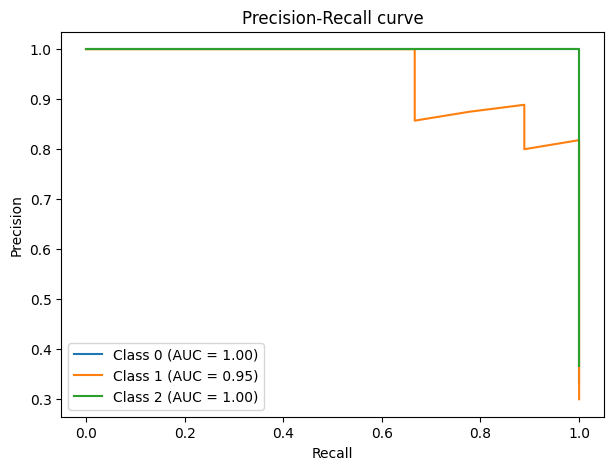

Η κλάση με το υψηλότερο AUC: Κλάση 2


In [14]:
from ucimlrepo import fetch_ucirepo
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

iris = fetch_ucirepo(id=53)
X = iris.data.features
y = iris.data.targets

# Μετατρέπουμε τις κλάσεις σε δυαδική μορφή για κάθε κλάση
y_bin = label_binarize(y, classes=np.unique(y))

# Διαχωρισμός των δεδομένων
X_train, X_test, y_train_bin, y_test_bin = train_test_split(X, y_bin, test_size=0.2, random_state=42)

# Δημιουργία του νέου νευρωνικού δικτύου
neural_network = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam',
                               alpha=0.001, learning_rate_init=0.001, max_iter=200,
                               random_state=42)

# Εκπαίδευση του μοντέλου με τα δεδομένα εκπαίδευσης σε δυαδική μορφή
neural_network.fit(X_train, y_train_bin)

# Πρόβλεψη πιθανοτήτων
y_scores = neural_network.predict_proba(X_test)

# Υπολογισμός των καμπυλών precision-recall και των AUC
precision = dict()
recall = dict()
auc_score = dict()
for i in range(y_bin.shape[1]):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_scores[:, i])
    auc_score[i] = auc(recall[i], precision[i])

# Σχεδιασμός των καμπυλών
plt.figure(figsize=(7, 5))
for i in range(y_bin.shape[1]):
    plt.plot(recall[i], precision[i], label='Class {0} (AUC = {1:0.2f})'
                                           ''.format(i, auc_score[i]))

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend(loc="best")
plt.show()

# Εκτύπωση
best_class = max(auc_score, key=auc_score.get)
print(f'Η κλάση με το υψηλότερο AUC: Κλάση {best_class}')
